In [503]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [504]:
data = pd.read_csv('../bitcoin_data/raw/btc_daily_11_years.csv')

In [505]:
data.head()

,Date,Open,High,Low,Close,Volume
0,2015-06-27,243.548996,251.339005,243.117004,250.990005,20488600
1,2015-06-28,250.955002,251.171997,247.434006,249.011002,15137600
2,2015-06-29,248.720993,257.173004,248.580994,257.063995,34742900
3,2015-06-30,257.036011,267.867004,255.945999,263.071991,44533800
4,2015-07-01,263.345001,265.171997,255.774002,258.621002,27029800


In [506]:
data.tail()

,Date,Open,High,Low,Close,Volume
4013,2026-06-22,63240.789062,65544.000000,63233.531250,63952.105469,26561496819
4014,2026-06-23,63952.792969,64196.562500,61893.207031,62668.019531,29608942370
4015,2026-06-24,62663.031250,63097.757812,59029.855469,60995.132812,42644106535
4016,2026-06-25,60992.070312,61868.906250,58075.921875,59721.675781,40625024718
4017,2026-06-26,59712.054688,60647.187500,58269.125000,60016.429688,41502864671


In [507]:
## Check missing values
data.isnull().sum()

Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

In [508]:
data.columns = data.columns.str.lower()

In [509]:
df = data.copy()

##### Feature Engineering

In [510]:
def calculate_rsi(close, period=14):
    """
    Wilder-style RSI calculation.

    close: pandas Series of closing prices
    period: RSI period, e.g. 14, 21, 30
    """

    delta = close.diff()

    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.ewm(alpha=1 / period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1 / period, adjust=False).mean()

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))

    return rsi


def create_rsi_features(df):
    """
    df must contain a 'close' column.
    Creates RSI features.
    """

    df = df.copy()

    df["RSI_7"] = calculate_rsi(df["close"], period=7)
    df["RSI_14"] = calculate_rsi(df["close"], period=14)
    df["RSI_21"] = calculate_rsi(df["close"], period=21)
    df["RSI_30"] = calculate_rsi(df["close"], period=30)

    df["RSI_7_change"] = df["RSI_7"].diff()

    df["RSI_14_above_50"] = (df["RSI_14"] > 50).astype(int)
    df["RSI_14_below_50"] = (df["RSI_14"] < 50).astype(int)
    df["RSI_14_overbought_70"] = (df["RSI_14"] > 70).astype(int)
    df["RSI_14_oversold_30"] = (df["RSI_14"] < 30).astype(int)

    return df

In [511]:
def compute_atr(df, window=14):
    """
    Simple rolling ATR calculation.

    df must contain: 'high', 'low', 'close'
    """

    high_low = df["high"] - df["low"]
    high_close = (df["high"] - df["close"].shift(1)).abs()
    low_close = (df["low"] - df["close"].shift(1)).abs()

    true_range = pd.concat(
        [high_low, high_close, low_close],
        axis=1
    ).max(axis=1)

    atr = true_range.rolling(window=window).mean()

    return atr


def rolling_zscore(series, window):
    """
    Rolling z-score calculation.
    """

    mean = series.rolling(window=window).mean()
    std = series.rolling(window=window).std()

    return (series - mean) / std

In [512]:
def calculate_macd(close, fast_period=12, slow_period=26, signal_period=9):
    """
    MACD calculation using exponential moving averages.

    close: pandas Series of closing prices
    fast_period: short EMA period, usually 12
    slow_period: long EMA period, usually 26
    signal_period: signal line EMA period, usually 9
    """

    ema_fast = close.ewm(span=fast_period, adjust=False).mean()
    ema_slow = close.ewm(span=slow_period, adjust=False).mean()

    macd = ema_fast - ema_slow
    macd_signal = macd.ewm(span=signal_period, adjust=False).mean()
    macd_hist = macd - macd_signal

    return macd, macd_signal, macd_hist


def create_macd_features(df):
    """
    df must contain a 'close' column.
    Creates MACD features.
    """

    df = df.copy()

    df["macd"], df["macd_signal"], df["macd_hist"] = calculate_macd(
        df["close"],
        fast_period=12,
        slow_period=26,
        signal_period=9
    )

    df["macd_bullish"] = (df["macd"] > df["macd_signal"]).astype(int)
    df["macd_bearish"] = (df["macd"] < df["macd_signal"]).astype(int)

    df["macd_above_zero"] = (df["macd"] > 0).astype(int)
    df["macd_below_zero"] = (df["macd"] < 0).astype(int)

    df["macd_hist_positive"] = (df["macd_hist"] > 0).astype(int)
    df["macd_hist_negative"] = (df["macd_hist"] < 0).astype(int)

    df["macd_change"] = df["macd"].diff()
    df["macd_signal_change"] = df["macd_signal"].diff()
    df["macd_hist_change"] = df["macd_hist"].diff()

    df["macd_bullish_cross"] = (
        (df["macd"] > df["macd_signal"]) &
        (df["macd"].shift(1) <= df["macd_signal"].shift(1))
    ).astype(int)

    df["macd_bearish_cross"] = (
        (df["macd"] < df["macd_signal"]) &
        (df["macd"].shift(1) >= df["macd_signal"].shift(1))
    ).astype(int)

    return df

In [513]:
def calculate_bollinger_bands(close, window=20, num_std=2):
    """
    Bollinger Bands calculation.

    close: pandas Series of closing prices
    window: rolling window period, usually 20
    num_std: number of standard deviations, usually 2
    """

    bb_middle = close.rolling(window=window).mean()
    bb_std = close.rolling(window=window).std()

    bb_upper = bb_middle + num_std * bb_std
    bb_lower = bb_middle - num_std * bb_std

    bb_width = (bb_upper - bb_lower) / bb_middle
    bb_percent_b = (close - bb_lower) / (bb_upper - bb_lower)

    return bb_middle, bb_upper, bb_lower, bb_width, bb_percent_b


def create_bollinger_band_features(df):
    """
    df must contain a 'close' column.
    Creates Bollinger Band features.
    """

    df = df.copy()

    (
        df["bb_middle"],
        df["bb_upper"],
        df["bb_lower"],
        df["bb_width"],
        df["bb_percent_b"]
    ) = calculate_bollinger_bands(
        df["close"],
        window=20,
        num_std=2
    )

    df["price_above_bb_upper"] = (df["close"] > df["bb_upper"]).astype(int)
    df["price_below_bb_lower"] = (df["close"] < df["bb_lower"]).astype(int)

    df["price_above_bb_middle"] = (df["close"] > df["bb_middle"]).astype(int)
    df["price_below_bb_middle"] = (df["close"] < df["bb_middle"]).astype(int)

    df["bb_width_change"] = df["bb_width"].diff()
    df["bb_percent_b_change"] = df["bb_percent_b"].diff()

    df["bb_squeeze"] = (
        df["bb_width"] < df["bb_width"].rolling(window=20).mean()
    ).astype(int)

    return df

In [514]:
def calculate_fibonacci_levels(df, window=20):
    """
    Calculates rolling Fibonacci retracement levels.

    df must contain:
    - high
    - low
    - close

    window: rolling lookback period
    """

    rolling_high = df["high"].rolling(window=window).max()
    rolling_low = df["low"].rolling(window=window).min()

    price_range = rolling_high - rolling_low

    fib_0 = rolling_low
    fib_236 = rolling_high - 0.236 * price_range
    fib_382 = rolling_high - 0.382 * price_range
    fib_500 = rolling_high - 0.500 * price_range
    fib_618 = rolling_high - 0.618 * price_range
    fib_786 = rolling_high - 0.786 * price_range
    fib_100 = rolling_high

    return {
        "fib_high": rolling_high,
        "fib_low": rolling_low,
        "fib_0": fib_0,
        "fib_236": fib_236,
        "fib_382": fib_382,
        "fib_500": fib_500,
        "fib_618": fib_618,
        "fib_786": fib_786,
        "fib_100": fib_100
    }

In [515]:
def create_fibonacci_features(df, window=20):
    """
    Creates Fibonacci retracement technical indicator features.

    df must contain:
    - high
    - low
    - close
    """

    df = df.copy()

    fib_levels = calculate_fibonacci_levels(df, window=window)

    df["fib_high"] = fib_levels["fib_high"]
    df["fib_low"] = fib_levels["fib_low"]
    df["fib_0"] = fib_levels["fib_0"]
    df["fib_236"] = fib_levels["fib_236"]
    df["fib_382"] = fib_levels["fib_382"]
    df["fib_500"] = fib_levels["fib_500"]
    df["fib_618"] = fib_levels["fib_618"]
    df["fib_786"] = fib_levels["fib_786"]
    df["fib_100"] = fib_levels["fib_100"]

    # Range between rolling high and low
    df["fib_range"] = df["fib_high"] - df["fib_low"]

    # Close position inside Fibonacci range
    df["fib_position"] = (
        (df["close"] - df["fib_low"]) / df["fib_range"]
    )

    # Distance from close to each Fibonacci level
    df["dist_to_fib_236"] = (df["close"] - df["fib_236"]) / df["close"]
    df["dist_to_fib_382"] = (df["close"] - df["fib_382"]) / df["close"]
    df["dist_to_fib_500"] = (df["close"] - df["fib_500"]) / df["close"]
    df["dist_to_fib_618"] = (df["close"] - df["fib_618"]) / df["close"]
    df["dist_to_fib_786"] = (df["close"] - df["fib_786"]) / df["close"]

    # Binary features: price above Fibonacci levels
    df["close_above_fib_236"] = (df["close"] > df["fib_236"]).astype(int)
    df["close_above_fib_382"] = (df["close"] > df["fib_382"]).astype(int)
    df["close_above_fib_500"] = (df["close"] > df["fib_500"]).astype(int)
    df["close_above_fib_618"] = (df["close"] > df["fib_618"]).astype(int)
    df["close_above_fib_786"] = (df["close"] > df["fib_786"]).astype(int)

    # Binary features: price below Fibonacci levels
    df["close_below_fib_236"] = (df["close"] < df["fib_236"]).astype(int)
    df["close_below_fib_382"] = (df["close"] < df["fib_382"]).astype(int)
    df["close_below_fib_500"] = (df["close"] < df["fib_500"]).astype(int)
    df["close_below_fib_618"] = (df["close"] < df["fib_618"]).astype(int)
    df["close_below_fib_786"] = (df["close"] < df["fib_786"]).astype(int)

    # Change in Fibonacci position
    df["fib_position_change"] = df["fib_position"].diff()

    return df

In [516]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

df = create_rsi_features(df)
df = create_macd_features(df)
df = create_bollinger_band_features(df)

df["atr_14"] = compute_atr(df, window=14)
df["atr_14_zscore"] = rolling_zscore(df["atr_14"], window=20)


In [517]:
# Target: next day percentage change
df["target_pct_change_1d"] = ((df["close"].shift(-1) - df["close"]) / df["close"]) * 100

In [519]:
lag_base_features = [
    # Price / volume
    "close",
    "volume",

    # RSI momentum
    "RSI_14",
    "RSI_21",
    "RSI_30",
    "RSI_14_change",

    # MACD trend / momentum
    "macd",
    "macd_signal",
    "macd_hist",
    "macd_change",
    "macd_signal_change",
    "macd_hist_change",

    # Bollinger volatility / price position
    "bb_width",
    "bb_percent_b",
    "bb_width_change",
    "bb_percent_b_change",

    # ATR volatility
    "atr_14",
    "atr_14_zscore",

    # Fibonacci position
    "fib_position",
    "fib_position_change",
    "dist_to_fib_236",
    "dist_to_fib_382",
    "dist_to_fib_500",
    "dist_to_fib_618",
    "dist_to_fib_786"
]

In [520]:
df = create_fibonacci_features(df, window=20)

In [521]:
features = base_features + lag_features

##### Target

In [522]:
target = "target_pct_change_1d"

In [523]:
df = df.dropna().reset_index(drop=True)

In [524]:
target = "target_pct_change_1d"

In [525]:
X = df[features]
y = df[target]

KeyError: "['RSI_14_change', 'open_lag_1', 'open_lag_2', 'open_lag_3', 'open_lag_5', 'open_lag_7', 'open_lag_14', 'high_lag_1', 'high_lag_2', 'high_lag_3', 'high_lag_5', 'high_lag_7', 'high_lag_14', 'low_lag_1', 'low_lag_2', 'low_lag_3', 'low_lag_5', 'low_lag_7', 'low_lag_14', 'close_lag_1', 'close_lag_2', 'close_lag_3', 'close_lag_5', 'close_lag_7', 'close_lag_14', 'volume_lag_1', 'volume_lag_2', 'volume_lag_3', 'volume_lag_5', 'volume_lag_7', 'volume_lag_14', 'RSI_14_lag_1', 'RSI_14_lag_2', 'RSI_14_lag_3', 'RSI_14_lag_5', 'RSI_14_lag_7', 'RSI_14_lag_14', 'RSI_21_lag_1', 'RSI_21_lag_2', 'RSI_21_lag_3', 'RSI_21_lag_5', 'RSI_21_lag_7', 'RSI_21_lag_14', 'RSI_30_lag_1', 'RSI_30_lag_2', 'RSI_30_lag_3', 'RSI_30_lag_5', 'RSI_30_lag_7', 'RSI_30_lag_14', 'RSI_14_change_lag_1', 'RSI_14_change_lag_2', 'RSI_14_change_lag_3', 'RSI_14_change_lag_5', 'RSI_14_change_lag_7', 'RSI_14_change_lag_14', 'RSI_14_above_50_lag_1', 'RSI_14_above_50_lag_2', 'RSI_14_above_50_lag_3', 'RSI_14_above_50_lag_5', 'RSI_14_above_50_lag_7', 'RSI_14_above_50_lag_14', 'RSI_14_below_50_lag_1', 'RSI_14_below_50_lag_2', 'RSI_14_below_50_lag_3', 'RSI_14_below_50_lag_5', 'RSI_14_below_50_lag_7', 'RSI_14_below_50_lag_14', 'RSI_14_overbought_70_lag_1', 'RSI_14_overbought_70_lag_2', 'RSI_14_overbought_70_lag_3', 'RSI_14_overbought_70_lag_5', 'RSI_14_overbought_70_lag_7', 'RSI_14_overbought_70_lag_14', 'RSI_14_oversold_30_lag_1', 'RSI_14_oversold_30_lag_2', 'RSI_14_oversold_30_lag_3', 'RSI_14_oversold_30_lag_5', 'RSI_14_oversold_30_lag_7', 'RSI_14_oversold_30_lag_14', 'macd_lag_1', 'macd_lag_2', 'macd_lag_3', 'macd_lag_5', 'macd_lag_7', 'macd_lag_14', 'macd_signal_lag_1', 'macd_signal_lag_2', 'macd_signal_lag_3', 'macd_signal_lag_5', 'macd_signal_lag_7', 'macd_signal_lag_14', 'macd_hist_lag_1', 'macd_hist_lag_2', 'macd_hist_lag_3', 'macd_hist_lag_5', 'macd_hist_lag_7', 'macd_hist_lag_14', 'macd_bullish_lag_1', 'macd_bullish_lag_2', 'macd_bullish_lag_3', 'macd_bullish_lag_5', 'macd_bullish_lag_7', 'macd_bullish_lag_14', 'macd_bearish_lag_1', 'macd_bearish_lag_2', 'macd_bearish_lag_3', 'macd_bearish_lag_5', 'macd_bearish_lag_7', 'macd_bearish_lag_14', 'macd_above_zero_lag_1', 'macd_above_zero_lag_2', 'macd_above_zero_lag_3', 'macd_above_zero_lag_5', 'macd_above_zero_lag_7', 'macd_above_zero_lag_14', 'macd_below_zero_lag_1', 'macd_below_zero_lag_2', 'macd_below_zero_lag_3', 'macd_below_zero_lag_5', 'macd_below_zero_lag_7', 'macd_below_zero_lag_14', 'macd_hist_positive_lag_1', 'macd_hist_positive_lag_2', 'macd_hist_positive_lag_3', 'macd_hist_positive_lag_5', 'macd_hist_positive_lag_7', 'macd_hist_positive_lag_14', 'macd_hist_negative_lag_1', 'macd_hist_negative_lag_2', 'macd_hist_negative_lag_3', 'macd_hist_negative_lag_5', 'macd_hist_negative_lag_7', 'macd_hist_negative_lag_14', 'macd_change_lag_1', 'macd_change_lag_2', 'macd_change_lag_3', 'macd_change_lag_5', 'macd_change_lag_7', 'macd_change_lag_14', 'macd_signal_change_lag_1', 'macd_signal_change_lag_2', 'macd_signal_change_lag_3', 'macd_signal_change_lag_5', 'macd_signal_change_lag_7', 'macd_signal_change_lag_14', 'macd_hist_change_lag_1', 'macd_hist_change_lag_2', 'macd_hist_change_lag_3', 'macd_hist_change_lag_5', 'macd_hist_change_lag_7', 'macd_hist_change_lag_14', 'macd_bullish_cross_lag_1', 'macd_bullish_cross_lag_2', 'macd_bullish_cross_lag_3', 'macd_bullish_cross_lag_5', 'macd_bullish_cross_lag_7', 'macd_bullish_cross_lag_14', 'macd_bearish_cross_lag_1', 'macd_bearish_cross_lag_2', 'macd_bearish_cross_lag_3', 'macd_bearish_cross_lag_5', 'macd_bearish_cross_lag_7', 'macd_bearish_cross_lag_14', 'bb_middle_lag_1', 'bb_middle_lag_2', 'bb_middle_lag_3', 'bb_middle_lag_5', 'bb_middle_lag_7', 'bb_middle_lag_14', 'bb_upper_lag_1', 'bb_upper_lag_2', 'bb_upper_lag_3', 'bb_upper_lag_5', 'bb_upper_lag_7', 'bb_upper_lag_14', 'bb_lower_lag_1', 'bb_lower_lag_2', 'bb_lower_lag_3', 'bb_lower_lag_5', 'bb_lower_lag_7', 'bb_lower_lag_14', 'bb_width_lag_1', 'bb_width_lag_2', 'bb_width_lag_3', 'bb_width_lag_5', 'bb_width_lag_7', 'bb_width_lag_14', 'bb_percent_b_lag_1', 'bb_percent_b_lag_2', 'bb_percent_b_lag_3', 'bb_percent_b_lag_5', 'bb_percent_b_lag_7', 'bb_percent_b_lag_14', 'price_above_bb_upper_lag_1', 'price_above_bb_upper_lag_2', 'price_above_bb_upper_lag_3', 'price_above_bb_upper_lag_5', 'price_above_bb_upper_lag_7', 'price_above_bb_upper_lag_14', 'price_below_bb_lower_lag_1', 'price_below_bb_lower_lag_2', 'price_below_bb_lower_lag_3', 'price_below_bb_lower_lag_5', 'price_below_bb_lower_lag_7', 'price_below_bb_lower_lag_14', 'price_above_bb_middle_lag_1', 'price_above_bb_middle_lag_2', 'price_above_bb_middle_lag_3', 'price_above_bb_middle_lag_5', 'price_above_bb_middle_lag_7', 'price_above_bb_middle_lag_14', 'price_below_bb_middle_lag_1', 'price_below_bb_middle_lag_2', 'price_below_bb_middle_lag_3', 'price_below_bb_middle_lag_5', 'price_below_bb_middle_lag_7', 'price_below_bb_middle_lag_14', 'bb_width_change_lag_1', 'bb_width_change_lag_2', 'bb_width_change_lag_3', 'bb_width_change_lag_5', 'bb_width_change_lag_7', 'bb_width_change_lag_14', 'bb_percent_b_change_lag_1', 'bb_percent_b_change_lag_2', 'bb_percent_b_change_lag_3', 'bb_percent_b_change_lag_5', 'bb_percent_b_change_lag_7', 'bb_percent_b_change_lag_14', 'bb_squeeze_lag_1', 'bb_squeeze_lag_2', 'bb_squeeze_lag_3', 'bb_squeeze_lag_5', 'bb_squeeze_lag_7', 'bb_squeeze_lag_14', 'atr_14_lag_1', 'atr_14_lag_2', 'atr_14_lag_3', 'atr_14_lag_5', 'atr_14_lag_7', 'atr_14_lag_14', 'atr_14_zscore_lag_1', 'atr_14_zscore_lag_2', 'atr_14_zscore_lag_3', 'atr_14_zscore_lag_5', 'atr_14_zscore_lag_7', 'atr_14_zscore_lag_14'] not in index"

In [ ]:
split_date = pd.Timestamp("2026-01-01")

train_mask = df["date"] < split_date
test_mask = df["date"] >= split_date

X_train = df.loc[train_mask, features]
X_test = df.loc[test_mask, features]

y_train = df.loc[train_mask, target]
y_test = df.loc[test_mask, target]

dates_test = df.loc[test_mask, "date"]

In [ ]:
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 1.8432321159708178
RMSE: 2.634256257961939
R2 Score: -0.0237171979014148


In [ ]:
results = pd.DataFrame({
    "date": dates_test.values,
    "actual_pct_change_1d": y_test.values,
    "predicted_pct_change_1d": y_pred
})

print(results.tail())

          date  actual_pct_change_1d  predicted_pct_change_1d
170 2026-06-20             -1.559997                -0.276053
171 2026-06-21              1.129972                 0.366925
172 2026-06-22             -2.007887                 0.313922
173 2026-06-23             -2.669442                 0.243781
174 2026-06-24             -2.087801                 0.518424


##### Plot Actual vs Predicted

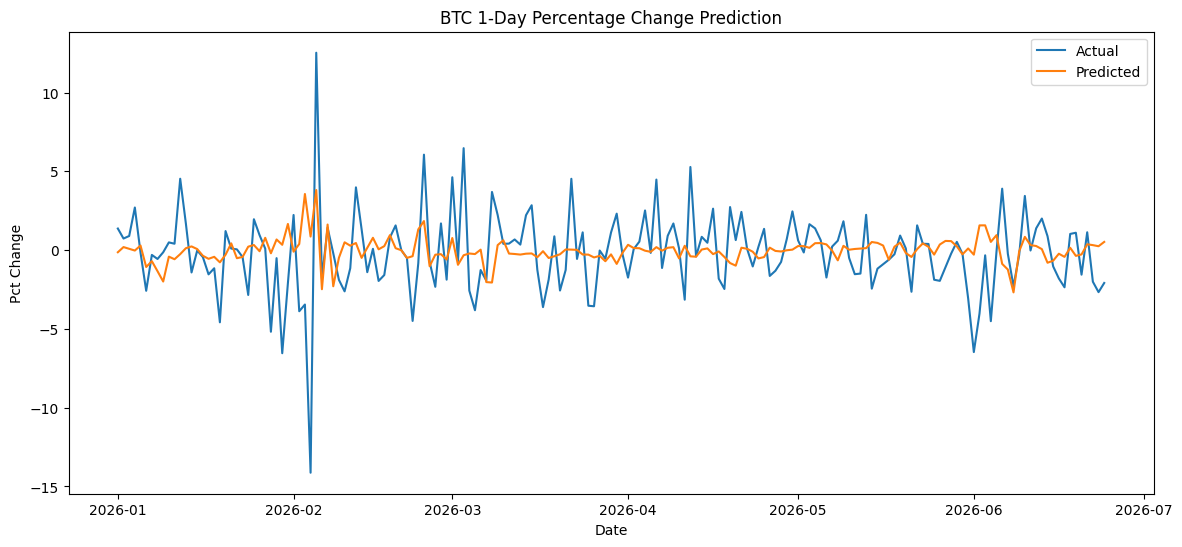

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(results["date"], results["actual_pct_change_1d"], label="Actual")
plt.plot(results["date"], results["predicted_pct_change_1d"], label="Predicted")
plt.legend()
plt.title("BTC 1-Day Percentage Change Prediction")
plt.xlabel("Date")
plt.ylabel("Pct Change")
plt.show()

In [ ]:
importance = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

importance

,feature,importance
28,bb_upper,0.013422
54,low_lag_2,0.013221
214,bb_upper_lag_14,0.011756
216,bb_lower_lag_2,0.011483
207,bb_middle_lag_7,0.011452
...,...,...
146,macd_bearish_lag_5,0.000000
147,macd_bearish_lag_7,0.000000
148,macd_bearish_lag_14,0.000000
203,bb_middle_lag_1,0.000000


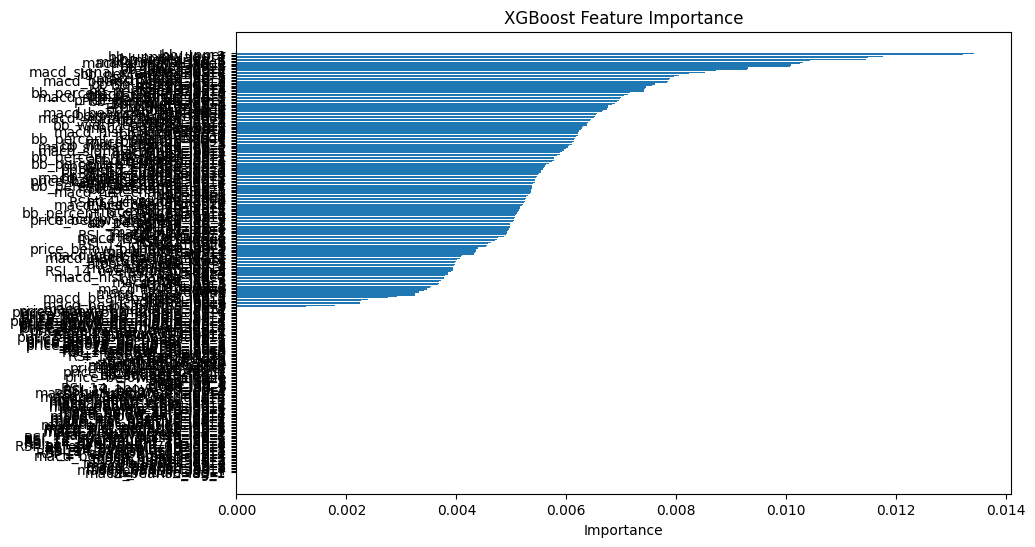

In [ ]:
plt.figure(figsize=(10, 6))
plt.barh(importance["feature"], importance["importance"])
plt.gca().invert_yaxis()
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.show()

In [ ]:
results["actual_direction"] = np.where(results["actual_pct_change_1d"] > 0, 1, 0)
results["predicted_direction"] = np.where(results["predicted_pct_change_1d"] > 0, 1, 0)

direction_accuracy = (
    results["actual_direction"] == results["predicted_direction"]
).mean()

print("Direction Accuracy:", direction_accuracy)

Direction Accuracy: 0.5428571428571428


In [ ]:
df.columns

Index(['date', 'open', 'high', 'low', 'close', 'volume', 'RSI_14', 'RSI_21',
       'RSI_30', 'RSI_14_change',
       ...
       'atr_14_lag_7', 'atr_14_lag_14', 'atr_14_zscore_lag_1',
       'atr_14_zscore_lag_2', 'atr_14_zscore_lag_3', 'atr_14_zscore_lag_5',
       'atr_14_zscore_lag_7', 'atr_14_zscore_lag_14', 'RSI_7', 'RSI_7_change'],
      dtype='str', length=291)